# Desintégrase o protón?

### Boletín guiado (versión simple): o límite de Super-Kamiokande a $p \to e^+ + \pi^0$

Jose A. Hernando

*Departamento de Física de Partículas. Universidade de Santiago de Compostela*

In [1]:
# Configuración e importacións
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as units
from scipy.stats import poisson, binom

import sys; sys.path.append('..')   # fnyp está en notebooks/

try:
    from fnyp import common as fn
except ModuleNotFoundError:      # en Google Colab hai que traer antes o repositorio
    !git clone -q https://github.com/xabiercidvidal/USC-FNeP.git
    import sys; sys.path.append('USC-FNeP/notebooks')
    from fnyp import common as fn

fn.version()

 Last version  Sat Oct  3 23:38:16 2026


## Obxectivos

* Ler o *abstract* dun artigo de busca e extraer os números relevantes.

* Identificar os **brancos** e contalos: os protóns de Super-Kamiokande (SK).

* Entender a **exposición**: $N_0$ protóns durante $T$ anos equivalen a $T N_0$ protóns durante un ano.

* Estimar o número de desintegracións esperadas cando $\tau \gg t$.

* Entender que, con poucos sucesos, o número observado segue unha **distribución de Poisson**.

* Se non se observa nada, fixar un **límite ao 90% de nivel de confianza** (CL) e comprobar que significa con experimentos simulados.

* Ver que con **fondo** as cousas se complican.

## O problema

No Modelo Estándar o número bariónico $B$ consérvase; isto implica que o protón non se desintegra, pois é o barión máis lixeiro.

As teorías de Gran Unificación (GUT) sitúan quarks e leptóns nos mesmos multipletes e predín que o protón se desintegra, isto é, violan a conservación do número bariónico, con vidas medias da orde de $10^{34}$–$10^{36}$ anos.

A canle favorita de moitas GUT é:

$$
p \to e^+ + \pi^0
$$

SK non mide a vida media total do protón $\tau$, senón a **vida media parcial** $\tau/\mathcal{B}$ da canle que busca,
onde $\mathcal{B}$ é a súa fracción de desintegración.

## Super-Kamiokande

| |
| :--: |
| <img src="../imgs/leptons_SK.png" width = 460 align = "center"> |
| Super-Kamiokande a) debuxo do detector b) principio de detección [SK, MT13.2] |

Tanque cilíndrico de auga ultrapura: 50 kt, 11 k PMT, a 1000 m baixo a montaña Ikenoyama (Xapón).

Toma datos desde 1996. O seu sucesor, Hyper-Kamiokande (HK), de 260 kt, conta con participación da USC.

## O artigo

Super-Kamiokande Collaboration, *Search for proton decay via $p\to e^+\pi^0$ and $p\to \mu^+\pi^0$
with an enlarged fiducial volume in Super-Kamiokande I-IV*,
Phys. Rev. D 102, 112011 (2020), [arXiv:2010.16098](https://arxiv.org/abs/2010.16098)

> We have searched for proton decay via $p\to e^+\pi^0$ and $p\to \mu^+\pi^0$ modes with the enlarged fiducial volume data of
> Super-Kamiokande from April 1996 to May 2018, which corresponds to 450 kton$\cdot$years exposure.
> We have accumulated about 25% more livetime and enlarged the fiducial volume of the Super-Kamiokande detector
> from 22.5 kton to 27.2 kton for this analysis, so that 144 kton$\cdot$years of data, including
> 78 kton$\cdot$years of additional fiducial volume data, has been newly analyzed.
> No candidates have been found for $p\to e^+\pi^0$ and one candidate remains for $p\to \mu^+\pi^0$
> in the conventional 22.5 kton fiducial volume and it is consistent with the atmospheric neutrino background prediction.
> We set lower limits on the partial lifetime for each of these modes:
> $\tau/Br(p\to e^+\pi^0) > 2.4 \times 10^{34}$ years and $\tau/Br(p\to \mu^+\pi^0) > 1.6 \times 10^{34}$ years
> at 90% confidence level.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Ler un *abstract*</b></p>

Le **só** o *abstract* e responde:

1. Que canles se buscan? Cantos anos de datos?
2. Que é a **exposición**? Por que se dá en kt·ano e non en anos?
3. Que é o **volume fiducial**? Por que é menor ca os 50 kt do tanque?
4. Que resultado se dá? É unha medida ou un límite?
5. Como se compara $2.4 \times 10^{34}$ anos coa idade do Universo, $1.38 \times 10^{10}$ anos?

</div>

<details>
<summary><b>Solución</b></summary>

1. $p\to e^+\pi^0$ e $p\to\mu^+\pi^0$. Datos de abril de 1996 a maio de 2018: 22 anos de calendario (con paradas).
2. Exposición = masa × tempo de toma de datos. O que conta é o número de **protóns·ano** observados:
   10 kt durante 1 ano equivalen a 1 kt durante 10 anos.
3. Volume interior, afastado das paredes, onde se aceptan os sucesos. Preto das paredes a reconstrución
   é peor e entra máis fondo (radioactividade da rocha e dos PMT, muóns cósmicos). É un compromiso
   entre masa e limpeza: a novidade do artigo é amplialo de 22.5 a 27.2 kt.
4. Non hai sinal: un **límite inferior** á vida media parcial ao 90% CL.
5. $2.4 \times 10^{34} / 1.38 \times 10^{10} \approx 1.7 \times 10^{24}$ veces a idade do Universo.
   E aínda así pódese medir! O truco: moitísimos protóns.

</details>

In [2]:
tau_lim = 2.4e34     # anos, tau/Br(p -> e+ pi0) ao 90% CL [SK 2020]
t_U     = 1.38e10    # anos, idade do Universo

print('tau/Br / idade do Universo = {:.1e}'.format(tau_lim / t_U))

tau/Br / idade do Universo = 1.7e+24


## Os brancos

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Os brancos</b></p>

Nunha busca de desintegracións, os **brancos** son as partículas que poderían desintegrarse.

Masa molar da auga $M_A = 18.015$ g/mol; $N_A = 6.022 \times 10^{23}$ $\mathrm{mol}^{-1}$.

1. Cales son os brancos en SK?
2. Cantos hai en 1 kt de auga? E no volume fiducial de 22.5 kt?

</div>

In [3]:
N_A = units.N_A      # 1/mol
M_A = 18.015         # g/mol, auga
kt  = 1e9            # g

n_mol   = kt / M_A * N_A     # moléculas de H2O por kt
p_total = 10 * n_mol         # protóns por kt: 2 do H e 8 do O
N0      = 22.5 * p_total     # protóns no volume fiducial

print('moléculas / kt       = {:.2e}'.format(n_mol))
print('protóns / kt         = {:.2e}'.format(p_total))
print('protóns en 22.5 kt   = {:.2e}'.format(N0))

moléculas / kt       = 3.34e+31
protóns / kt         = 3.34e+32
protóns en 22.5 kt   = 7.52e+33


<details>
<summary><b>Solución</b></summary>

1. Os protóns da auga: 2 libres (H) e 8 ligados no $^{16}$O por molécula. SK usa os 10.
2. $3.34 \times 10^{31}$ moléculas e $3.34 \times 10^{32}$ protóns por kt. En 22.5 kt, $N_0 = 7.52 \times 10^{33}$ protóns.

</details>

## A exposición

SK resume os seus datos nunha **exposición** de 450 kt·ano.

Para vidas medias moi longas ($\tau \gg t$), observar $N_0$ protóns durante $T$ anos é o mesmo que observar
$T\,N_0$ protóns durante un ano: só importa o produto $N_0\,T$, a exposición.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — A exposición</b></p>

Se todos os datos se tomasen co volume fiducial de 22.5 kt, cantos anos de toma de datos serían? E con 1 kt?

</div>

In [4]:
exposicion = 450 * p_total            # protóns x ano

print('anos con 22.5 kt = {:.0f}'.format(450 / 22.5))
print('anos con 1 kt    = {:.0f}'.format(450 / 1))
print('exposición       = {:.2e} protóns ano'.format(exposicion))

anos con 22.5 kt = 20
anos con 1 kt    = 450
exposición       = 1.50e+35 protóns ano


<details>
<summary><b>Solución</b></summary>

$450/22.5 = 20$ anos. Con 1 kt, 450 anos. (En realidade, SK combina períodos con 22.5 e 27.2 kt.)

En protóns: $450 \times 3.34 \times 10^{32} = 1.50 \times 10^{35}$ protóns·ano.

</details>

## Cantas desintegracións esperamos?

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Desintegracións esperadas</b></p>

Supón que $\tau/\mathcal{B}$ é xusto o límite de SK, $2.4 \times 10^{34}$ anos.
A eficiencia de selección de SK (fracción de desintegracións que detecta) é $\varepsilon = 0.37$.

1. Con $N_0$ protóns, cantos quedan tras un tempo $t$? Demostra que, se $t \ll \tau$, o número medio de desintegracións é $N_0\,t/\tau$.
2. Cantas desintegracións esperas detectar nun **ano** no volume fiducial de 22.5 kt? E coa exposición de 450 kt·ano?
3. Que masa de auga necesitas para detectar, en media, **unha** desintegración ao ano?

</div>

In [5]:
eps = 0.37                    # eficiencia de SK para p -> e+ pi0
tau = tau_lim                 # límite de SK para tau (anos)

print('nu en 1 ano (22.5 kt)       = {:.2f}'.format(eps * N0 * 1 / tau))
print('nu con 450 kt ano           = {:.2f}'.format(eps * exposicion / tau))
print('masa para nu = 1 ao ano     = {:.0f} kt'.format(tau / (eps * p_total)))

nu en 1 ano (22.5 kt)       = 0.12
nu con 450 kt ano           = 2.32
masa para nu = 1 ao ano     = 194 kt


<details>
<summary><b>Solución</b></summary>

1. $N(t) = N_0\,e^{-t/\tau} \simeq N_0\,(1 - t/\tau)$, logo desintégranse $N_0 - N(t) \simeq N_0\,t/\tau$.
2. SK detecta, en media, $\nu = \varepsilon N_0\,t/\tau$: $\nu = 0.12$ nun ano. Coa exposición total, $\nu = 2.3$.
   SK non viu ningunha: verémolo na tarefa *Non vemos nada*.
3. $\approx 190$ kt, como o volume fiducial de Hyper-Kamiokande (187 kt).
4. O número de desintegracións nunha canle vén dado por $N_i = \mathcal{B} \, N_0\,t/\tau =  N_0\,t \, (\mathcal{B}/\tau)$. En realidade, SK pon o límite en $\mathcal{B}/\tau$, dado que non poden separar os dous factores $\mathcal{B}, \tau$ a partir dos seus datos.

</details>

## A distribución de Poisson

Cada protón é un "intento" cunha probabilidade minúscula de desintegrarse no tempo $t$:

$$
p = \frac{t}{\tau} \sim 10^{-34}
$$

O número de desintegracións entre $N_0 \sim 10^{34}$ protóns segue unha **binomial** $B(n \,|\, N_0, p)$.

Cando $N_0 \to \infty$, $p \to 0$ con $\nu = N_0 p$ fixo, a binomial tende á **Poisson**:

$$
P(n \,|\, \nu) = \frac{\nu^n}{n!} \, e^{-\nu}, \qquad \langle n \rangle = \nu, \qquad \sigma_n = \sqrt{\nu}
$$

Só depende de $\nu$: tanto ten cantos protóns e canto tempo, só importa o número medio.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Poucos sucesos</b></p>

1. Demostra que, se $N_0 \to \infty$ e $p \to 0$ con $\nu = N_0 p$ fixo, a binomial tende á Poisson.
2. Simula o número de desintegracións detectadas en 10000 "anos" de SK (22.5 kt) para $\tau/\mathcal{B} = 2.4 \times 10^{34}$ anos
   e para $\tau/\mathcal{B} = 2.8 \times 10^{32}$ anos. Compara os histogramas coa Poisson.
   Cal é o resultado máis probable en cada caso? Con que probabilidade non se ve nada?

</div>

nu =  0.12: máis probable n = 0, P(0) = 0.89, P(1) = 0.1
nu =  9.94: máis probable n = 9, P(0) = 4.8e-05, P(1) = 0.00048


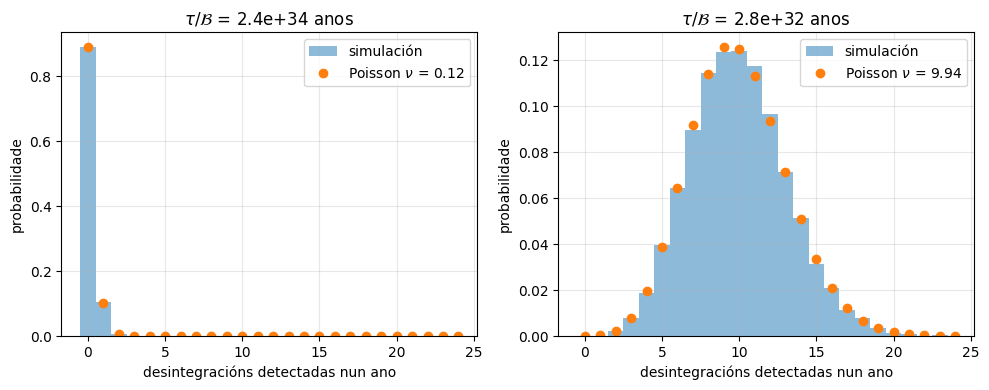

In [6]:
rng    = np.random.default_rng()
n_años = 10000
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, tau_i in zip(axs, (2.4e34, 2.8e32)):
    nu_i    = eps * N0 * 1 / tau_i
    cuentas = rng.poisson(nu_i, size=n_años)       # un número por cada 'ano' simulado
    ns = np.arange(0, 25)
    ax.hist(cuentas, bins=ns - 0.5, density=True, alpha=0.5, label='simulación')
    ax.plot(ns, poisson.pmf(ns, nu_i), 'o', label=r'Poisson $\nu$ = {:.2f}'.format(nu_i))
    ax.set_xlabel('desintegracións detectadas nun ano'); ax.set_ylabel('probabilidade')
    ax.set_title(r'$\tau/\mathcal{{B}}$ = {:.1e} anos'.format(tau_i))
    ax.grid(alpha=0.3); ax.legend()
    print('nu = {:5.2f}: máis probable n = {}, P(0) = {:.2g}, P(1) = {:.2g}'.format(
          nu_i, ns[np.argmax(poisson.pmf(ns, nu_i))], poisson.pmf(0, nu_i), poisson.pmf(1, nu_i)))
fig.tight_layout()

<details>
<summary><b>Solución</b></summary>

1. Con $p = \nu/N_0$:

$$
B(n \,|\, N_0, p) = \frac{\nu^n}{n!} \, \underbrace{\frac{N_0 (N_0-1) \cdots (N_0-n+1)}{N_0^n}}_{\to 1} \,
\underbrace{\left(1 - \frac{\nu}{N_0}\right)^{N_0}}_{\to e^{-\nu}} \,
\underbrace{\left(1 - \frac{\nu}{N_0}\right)^{-n}}_{\to 1}
\longrightarrow \frac{\nu^n}{n!} e^{-\nu}
$$

   Con $\sim 10^{34}$ protóns a Poisson é exacta a efectos prácticos.

2. $\nu = 0.12$ e $\nu = 10$ ao ano. Con $\nu = 0.12$ o máis probable é **non ver nada**: $P(0) = 89\%$, $P(1) = 10\%$.
   Con $\nu = 10$ o máis probable é ver 9 ou 10 e $P(0) = e^{-10} \approx 5 \times 10^{-5}$; a distribución é case gaussiana, con $\sigma = \sqrt{10} \approx 3.2$.

</details>

nu = 20.00


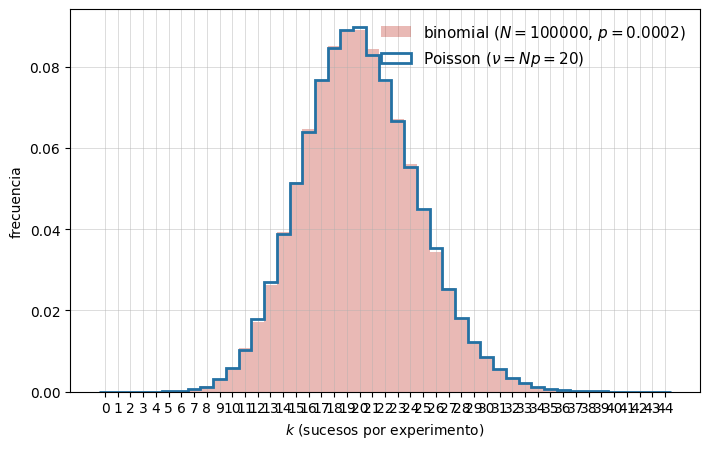

In [7]:
import numpy as np
import matplotlib.pyplot as plt

N, p  = 100000, 20e-5
nu    = N * p
print('nu = {:5.2f}'.format(nu));
n_exp = 200000                    # n.º de experimentos simulados

rng   = np.random.default_rng(1)
k_bin = rng.binomial(N, p, n_exp)
k_poi = rng.poisson(nu,  n_exp)

# variable discreta -> un bin por enteiro, centrado nel
kmax = max(k_bin.max(), k_poi.max())
bins = np.arange(-0.5, kmax + 1.5)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.hist(k_bin, bins=bins, density=True, color="#c0392b", alpha=0.35,
        label=f"binomial ($N = {N}$, $p = {p:g}$)")
ax.hist(k_poi, bins=bins, density=True, histtype="step", lw=2,
        color="#2471a3", label=rf"Poisson ($\nu = Np = {nu:g}$)")

#ax.set_yscale("log")               # quítao para escala lineal
ax.set_xticks(np.arange(kmax + 1))
ax.set_xlabel("$k$ (sucesos por experimento)")
ax.set_ylabel("frecuencia")
ax.grid(which="major", lw=0.6, alpha=0.5)
ax.legend(frameon=False, fontsize=11)
fig.tight_layout()
plt.show()

## Non vemos nada: que podemos dicir?

SK non observa ningunha desintegración $p \to e^+ + \pi^0$ ($n = 0$), cunha exposición de 450 kt·ano e sen fondo.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Non vemos nada</b></p>

1. Calcula $P(0 \,|\, \nu)$ para $\nu = 0.1, \, 1, \, 2.3, \, 5$. Hai algún valor de $\nu$ que sexa imposible? Podemos medir $\tau/\mathcal{B}$? Que necesitamos para dicir algo?
2. Co criterio do 90% CL (véxase a **Axuda** ao final), que valores de $\nu$ quedan excluídos? Que límite lle pos a $\tau/\mathcal{B}$? Compárao co de SK.
3. Que límite terías obtido esquecendo a eficiencia ($\varepsilon = 1$)? Por que non é correcto?

</div>

P(0 | nu = 0.1) = 0.905
P(0 | nu =   1) = 0.368
P(0 | nu = 2.3) = 0.100
P(0 | nu =   5) = 0.007

nu_90                  = 2.30
límite con eps = 0.37  = 2.4e+34 anos
límite con eps = 1     = 6.5e+34 anos


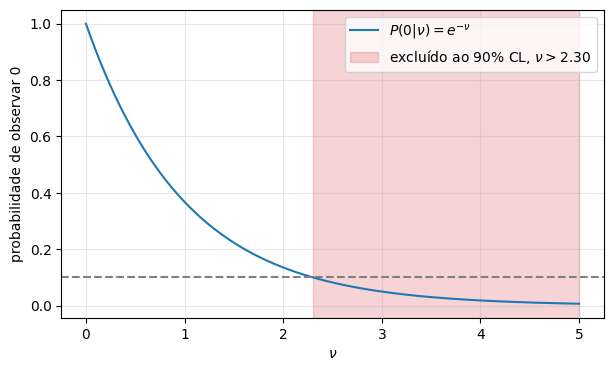

In [8]:
for nu_i in (0.1, 1, 2.3, 5):
    print('P(0 | nu = {:3}) = {:.3f}'.format(nu_i, poisson.pmf(0, nu_i)))

nu90 = -np.log(0.10)                  # n = 0: nu > 2.30 excluído ao 90% CL
print()
print('nu_90                  = {:.2f}'.format(nu90))
print('límite con eps = {:.2f}  = {:.1e} anos'.format(eps, eps * exposicion / nu90))
print('límite con eps = 1     = {:.1e} anos'.format(exposicion / nu90))

nus = np.linspace(0, 5, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nus, poisson.pmf(0, nus), label=r'$P(0 | \nu) = e^{-\nu}$')
ax.axhline(0.10, color='gray', ls='--')
ax.axvspan(nu90, 5, color='C3', alpha=0.2, label=r'excluído ao 90% CL, $\nu > {:.2f}$'.format(nu90))
ax.set_xlabel(r'$\nu$'); ax.set_ylabel('probabilidade de observar 0')
ax.grid(alpha=0.3); ax.legend();

<details>
<summary><b>Solución</b></summary>

1. $P(0 \,|\, \nu) = e^{-\nu}$: 0.90, 0.37, 0.10 e 0.007. Ningún $\nu$ é imposible, só cada vez máis improbable:
   cun único resultado $n = 0$ non se pode medir $\nu$. Fai falta un **criterio** para decidir a partir de que
   probabilidade descartamos un valor, e dicilo xunto co resultado: o nivel de confianza.

2. Exclúese $\nu$ se $e^{-\nu} < 0.10$, é dicir, $\nu > \ln 10 = 2.30$. Como $\nu = \varepsilon N_0 t/\tau$:

$$
\frac{\tau}{\mathcal{B}} > \frac{\varepsilon \, N_0 \, t}{2.30} = \frac{0.37 \times 1.50 \times 10^{35}}{2.30} = 2.4 \times 10^{34} \text{ anos} \qquad (90\%\ \mathrm{CL})
$$

   o límite de SK. Por iso, con $\tau/\mathcal{B}$ xusto no límite, esperabamos $\nu = 2.3$: é o valor fronteira.

3. $\tau/\mathcal{B} > 6.5 \times 10^{34}$ anos: un límite case tres veces máis forte, pero falso. SK só detecta o 37%
   das desintegracións (pérdese sinal nos cortes que rexeitan o fondo de neutrinos atmosféricos e pola absorción
   ou dispersión do $\pi^0$ no osíxeno): con $\varepsilon = 1$ supoñeriamos unha sensibilidade que non ten.

</details>

## Que significa o 90%? Experimentos simulados

Cómpre distinguir dous números:

* $\nu$: o número **esperado** de desintegracións detectadas. Fíxano a física ($\tau/\mathcal{B}$) e o experimento ($\varepsilon N_0 t$).

* $n$: o número **observado** nun experimento concreto. É enteiro e aleatorio, e segue unha Poisson de media $\nu$.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Experimentos que non ven nada</b></p>

Usa a exposición e a eficiencia de SK.

Para 30 valores de $\tau/\mathcal{B}$ entre $10^{33.5}$ e $10^{35.5}$ anos, xera 10000 experimentos como SK e debuxa
a fracción de experimentos que non ven nada ($n = 0$) fronte a $\tau/\mathcal{B}$.

Que fracción de experimentos non ve nada se $\tau/\mathcal{B} = 2.4 \times 10^{34}$ anos? Onde cruza a curva o 10%?
Que valores de $\tau/\mathcal{B}$ exclúe SK?

</div>

tau/B = 2.4e+34 anos: n = 0 no 10.0% dos experimentos


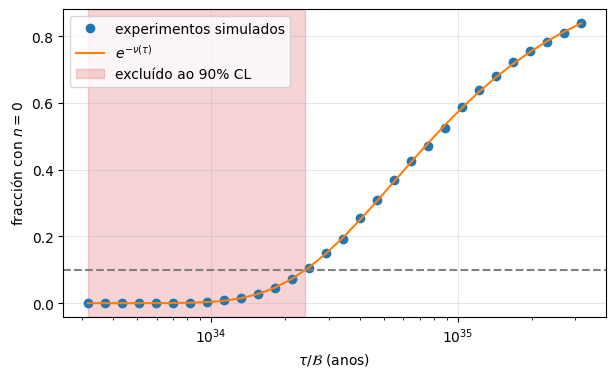

In [9]:
n_exp = 10000
taus  = np.logspace(33.5, 35.5, 30)                      # anos

frac0 = [np.mean(rng.poisson(eps * exposicion / tau_i, size=n_exp) == 0) for tau_i in taus]
f_lim = np.mean(rng.poisson(eps * exposicion / tau_lim, size=n_exp) == 0)
print('tau/B = {:.1e} anos: n = 0 no {:.1f}% dos experimentos'.format(tau_lim, 100 * f_lim))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(taus, frac0, 'o', label='experimentos simulados')
ax.plot(taus, np.exp(-eps * exposicion / taus), label=r'$e^{-\nu(\tau)}$')
ax.axhline(0.10, color='gray', ls='--')
ax.axvspan(taus[0], tau_lim, color='C3', alpha=0.2, label='excluído ao 90% CL')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau/\mathcal{B}$ (anos)'); ax.set_ylabel('fracción con $n = 0$')
ax.grid(alpha=0.3); ax.legend();

<details>
<summary><b>Solución</b></summary>

Con $\nu = 0.37 \times 1.50 \times 10^{35}/(\tau/\mathcal{B})$, a fracción con $n = 0$ segue $e^{-\nu}$ e medra con $\tau/\mathcal{B}$.

Para $\tau/\mathcal{B} = 2.4 \times 10^{34}$ anos, $\nu = 2.3$ e a fracción é $e^{-2.3} \approx 10\%$ (a simulación reprodúceo
dentro da súa flutuación estatística, $\sqrt{P(1-P)/10000} \approx 0.3\%$): a curva cruza o 10% xusto no límite de SK.

Para valores menores, menos do 10% dos experimentos vería $n = 0$: están **excluídos** ao 90% CL. Para valores maiores,
ver $n = 0$ é o normal: SK non pode dicir nada deles.

Que $\tau/\mathcal{B}$ estea xusto no límite non significa que non poida ser o verdadeiro: nese caso, o 10% dos experimentos non vería nada.

</details>

## E se hai fondo?

Algunhas interaccións de neutrinos atmosféricos imitan o sinal.

Se se esperan $b$ sucesos de **fondo** e $\nu_s$ de sinal, o criterio da Axuda xeneralízase a: $\nu_s$ está excluído ao 90% CL se

$$
P(n \leq n_{obs} \,|\, \nu_s + b) < 0.10
$$

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — O límite con fondo</b></p>

1. Se $n_{obs} = 0$ e $b = 3$, que límite obtés para $\nu_s$? Ten sentido?
2. En $p \to \mu^+ + \pi^0$ SK observa un candidato, con $b \approx 0.94$. Por que o seu límite é peor ($1.6$ fronte a $2.4 \times 10^{34}$ anos)?

</div>

In [10]:
from scipy.optimize import brentq

def nu_s_90(n_obs, b, cl=0.90):
    # Límite superior clásico no sinal: P(n <= n_obs | s + b) = 1 - cl
    f = lambda s: poisson.cdf(n_obs, s + b) - (1 - cl)
    return brentq(f, -b, 50)       # f(-b) = 0.9 > 0 e f(50) < 0

print('n_obs = 0, b = 3    : nu_s_90 = {:.2f}'.format(nu_s_90(0, 3)))
print('n_obs = 1, b = 0.94 : nu_s_90 = {:.2f}, factor fronte a n_obs = 0, b = 0: {:.2f}'.format(
      nu_s_90(1, 0.94), nu_s_90(1, 0.94) / nu_s_90(0, 0)))

n_obs = 0, b = 3    : nu_s_90 = -0.70
n_obs = 1, b = 0.94 : nu_s_90 = 2.95, factor fronte a n_obs = 0, b = 0: 1.28


<details>
<summary><b>Solución</b></summary>

1. $e^{-(\nu_s + 3)} < 0.10 \Rightarrow \nu_s > 2.30 - 3 = -0.70$: exclúese calquera sinal, mesmo $\nu_s = 0$! É absurdo
   e, ademais, premia un experimento con moito fondo que tivo a "sorte" de ver menos sucesos dos esperados.
   Con fondo fai falta un método máis coidadoso: [Feldman e Cousins](https://arxiv.org/abs/physics/9711021) (1998) dan
   $\nu_s \in [0, 1.08]$ neste caso. SK usa un método bayesiano.

2. Cun candidato hai que admitir máis sinal: $P(n \leq 1 \,|\, \nu_s + 0.94) = 0.10$ dá $\nu_s < 2.95$, fronte a $2.30$ con
   $n_{obs} = 0$, e o límite en $\tau/\mathcal{B}$ é un factor $\approx 1.3$ peor. A eficiencia de $\mu^+ + \pi^0$, algo menor,
   e os detalles da análise de SK explican o resto.

</details>

## Axuda: o límite ao 90% CL

Un valor de $\nu$ queda **excluído ao 90% CL** se, sendo certo, a probabilidade de obter un resultado como o observado
**ou máis extremo** (aquí, menos sucesos) é menor do 10%.

É dicir, se ese $\nu$ fose o verdadeiro, **máis do 90% dos experimentos observarían máis sucesos** ca os que vimos.

*Ollo*: non significa que haxa un 90% de probabilidade de que ese $\nu$ sexa falso.

## Resumo

* Os **brancos** de SK son os protóns da auga: $3.34 \times 10^{32}$ por kt, $7.5 \times 10^{33}$ no volume fiducial de 22.5 kt.

* Para $\tau \gg t$ só importa a **exposición** $N_0\,t$: SK acumula 450 kt·ano $= 1.5 \times 10^{35}$ protóns·ano.

* O número medio de desintegracións detectadas é $\nu = \varepsilon N_0 t/\tau$: con $\tau/\mathcal{B} \sim 10^{34}$ anos, $\lesssim 1$ ao ano en SK.

* O número observado segue unha **Poisson** de media $\nu$: con $\nu$ pequeno, o máis probable é non ver nada.

* Se non se observa nada, $\nu < 2.30$ ao 90% CL e $\tau/\mathcal{B} > \varepsilon N_0 t/2.30$: con $\varepsilon = 0.37$, o límite de SK, $2.4 \times 10^{34}$ anos.

* Se $\tau/\mathcal{B}$ estivese no límite, o 10% dos experimentos como SK non vería nada.

* Con **fondo**, o método simple dá resultados sen sentido: Feldman-Cousins ou métodos bayesianos.

* O límite medra coa exposición: de aí Hyper-Kamiokande.

## Bibliografía

* [SK2020] Super-Kamiokande Collaboration, Phys. Rev. D 102, 112011 (2020), [arXiv:2010.16098](https://arxiv.org/abs/2010.16098)

* [FC] G. J. Feldman, R. D. Cousins, Phys. Rev. D 57, 3873 (1998), [arXiv:physics/9711021](https://arxiv.org/abs/physics/9711021)

* [PDG] Particle Data Group, *Statistics* e *Grand Unified Theories*, [pdg.lbl.gov](https://pdg.lbl.gov/)

* [AB] A. Bettini, *Introduction to Elementary Particle Physics*, Cambridge U. Press.

* [MT] M. Thomson, *Modern Particle Physics*, Cambridge U. Press.